<a href="https://colab.research.google.com/github/mi31417/AI-Powered_Chatbot/blob/main/Causal%20AI%3A%20Effect%20of%20Low%20Birth%20Weight%20on%20Infant%20Mortality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

url_T="https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/refs/heads/master/datasets/TWINS/twin_pairs_T_3years_samesex.csv"
url_X="https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/refs/heads/master/datasets/TWINS/twin_pairs_X_3years_samesex.csv"
url_Y="https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/refs/heads/master/datasets/TWINS/twin_pairs_Y_3years_samesex.csv"

df_T=pd.read_csv(url_T)
df_X=pd.read_csv(url_X)
df_Y=pd.read_csv(url_Y)



In [ ]:
df_T.describe()

,Unnamed: 0,dbirwt_0,dbirwt_1
count,71345.000000,71345.000000,71345.000000
mean,35672.000000,2260.982073,2544.831761
std,20595.671815,625.168358,659.414930
min,0.000000,227.000000,234.000000
25%,17836.000000,1940.000000,2229.000000
50%,35672.000000,2353.000000,2637.000000
75%,53508.000000,2693.000000,2977.000000
max,71344.000000,4621.000000,6804.000000


In [ ]:
df_X.describe()

,Unnamed: 0.1,Unnamed: 0,pldel,birattnd,brstate,stoccfipb,mager8,ormoth,mrace,meduc6,...,feduc6,infant_id_0,infant_id_1,dlivord_min,dtotord_min,bord_0,bord_1,brstate_reg,stoccfipb_reg,mplbir_reg
count,71345.000000,71345.000000,71321.000000,71231.000000,71345.000000,71345.000000,71345.000000,69319.000000,71345.000000,67006.000000,...,56666.000000,71345.000000,71345.000000,64121.000000,64027.000000,64121.000000,64121.000000,71345.000000,71345.000000,71237.000000
mean,35672.000000,35672.000000,1.009787,1.052969,24.758189,27.584007,4.085570,0.209553,1.359002,3.407635,...,3.555483,141095.212292,141095.180517,2.108716,2.510082,1.525413,1.474587,3.994730,3.994085,3.551455
std,20595.671815,20595.671815,0.171234,0.333138,14.672375,15.595846,1.155485,0.773247,1.057218,1.109011,...,1.135022,80321.405970,80321.413703,1.265682,1.592072,0.499358,0.499358,2.541834,2.540995,2.431730
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,17836.000000,17836.000000,1.000000,1.000000,11.000000,13.000000,3.000000,0.000000,1.000000,3.000000,...,3.000000,71157.000000,71158.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000
50%,35672.000000,35672.000000,1.000000,1.000000,24.000000,27.000000,4.000000,0.000000,1.000000,3.000000,...,3.000000,141616.000000,141615.000000,2.000000,2.000000,2.000000,1.000000,4.000000,4.000000,3.000000
75%,53508.000000,53508.000000,1.000000,1.000000,37.000000,40.000000,5.000000,0.000000,1.000000,4.000000,...,5.000000,211264.000000,211265.000000,3.000000,3.000000,2.000000,2.000000,6.000000,6.000000,6.000000
max,71344.000000,71344.000000,5.000000,5.000000,59.000000,56.000000,8.000000,5.000000,9.000000,5.000000,...,5.000000,279062.000000,279061.000000,17.000000,21.000000,2.000000,2.000000,8.000000,8.000000,8.000000


In [ ]:
df_Y.describe()

,Unnamed: 0,mort_0,mort_1
count,71345.000000,71345.000000,71345.000000
mean,35672.000000,0.039470,0.032350
std,20595.671815,0.194712,0.176929
min,0.000000,0.000000,0.000000
25%,17836.000000,0.000000,0.000000
50%,35672.000000,0.000000,0.000000
75%,53508.000000,0.000000,0.000000
max,71344.000000,1.000000,1.000000


In [ ]:
print(df_T.head(10))
print(df_X.head(10))
print(df_Y.head(10))



   Unnamed: 0  dbirwt_0  dbirwt_1
0           0    2268.0    2296.0
1           1    2610.0    2650.0
2           2    1985.0    2098.0
3           3    2410.0    2420.0
4           4    2013.0    2637.0
5           5    2155.0    2693.0
6           6    3444.0    3912.0
7           7    2098.0    2778.0
8           8    2410.0    2835.0
9           9     936.0    1006.0
   Unnamed: 0.1  Unnamed: 0  pldel  birattnd  brstate  stoccfipb  mager8  \
0             0           0    1.0       1.0        1          1       3   
1             1           1    1.0       1.0        1          1       3   
2             2           2    1.0       1.0        1          1       5   
3             3           3    1.0       1.0        1          1       4   
4             4           4    1.0       1.0        1          1       5   
5             5           5    1.0       1.0        1          1       4   
6             6           6    1.0       1.0        1          1       3   
7             7   

In [ ]:
for i, col in enumerate(df_X.columns):
    print(f"{i}: {col}")

0: Unnamed: 0.1
1: Unnamed: 0
2: pldel
3: birattnd
4: brstate
5: stoccfipb
6: mager8
7: ormoth
8: mrace
9: meduc6
10: dmar
11: mplbir
12: mpre5
13: adequacy
14: orfath
15: frace
16: birmon
17: gestat10
18: csex
19: anemia
20: cardiac
21: lung
22: diabetes
23: herpes
24: hydra
25: hemo
26: chyper
27: phyper
28: eclamp
29: incervix
30: pre4000
31: preterm
32: renal
33: rh
34: uterine
35: othermr
36: tobacco
37: alcohol
38: cigar6
39: drink5
40: crace
41: data_year
42: nprevistq
43: dfageq
44: feduc6
45: infant_id_0
46: infant_id_1
47: dlivord_min
48: dtotord_min
49: bord_0
50: bord_1
51: brstate_reg
52: stoccfipb_reg
53: mplbir_reg


In [ ]:
missing_X=df_X.isnull().sum()
print(missing_X)

Unnamed: 0.1         0
Unnamed: 0           0
pldel               24
birattnd           114
brstate              0
stoccfipb            0
mager8               0
ormoth            2026
mrace                0
meduc6            4339
dmar                 0
mplbir             108
mpre5             1627
adequacy          3169
orfath           11822
frace            10260
birmon               0
gestat10             0
csex                 0
anemia            4240
cardiac           4240
lung              4240
diabetes          4240
herpes           10566
hydra             7086
hemo              7086
chyper            4240
phyper            4240
eclamp            4240
incervix          7086
pre4000           7086
preterm           7086
renal             4240
rh                5015
uterine           7720
othermr           4240
tobacco          19254
alcohol          17923
cigar6           19716
drink5           18319
crace                0
data_year            0
nprevistq         2350
dfageq     

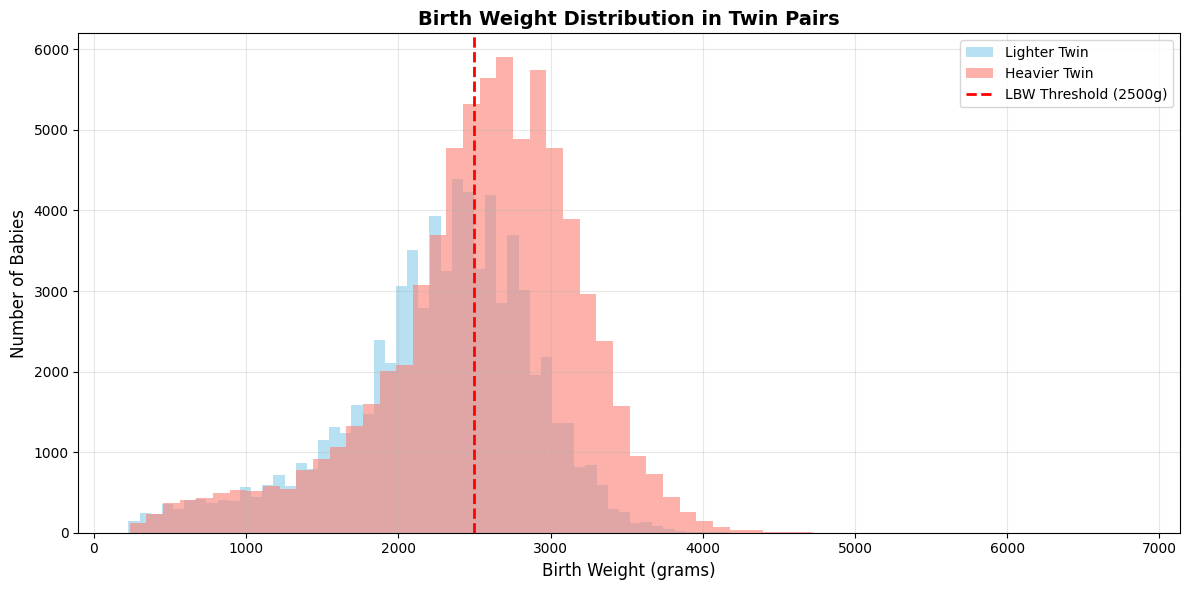

Lighter twin - Mean: 2261g
Heavier twin - Mean: 2545g
Babies < 2500g: 73,610


In [ ]:
# Visualization 1: Birth Weight Distribution
import matplotlib.pyplot as plt
import numpy as np

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot histogram for both twins
ax.hist(df_T['dbirwt_0'], bins=60, alpha=0.6, label='Lighter Twin', color='skyblue')
ax.hist(df_T['dbirwt_1'], bins=60, alpha=0.6, label='Heavier Twin', color='salmon')

# Add the LBW threshold line
ax.axvline(2500, color='red', linestyle='--', linewidth=2, label='LBW Threshold (2500g)')

# Labels
ax.set_xlabel('Birth Weight (grams)', fontsize=12)
ax.set_ylabel('Number of Babies', fontsize=12)
ax.set_title('Birth Weight Distribution in Twin Pairs', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print key statistics
print(f"Lighter twin - Mean: {df_T['dbirwt_0'].mean():.0f}g")
print(f"Heavier twin - Mean: {df_T['dbirwt_1'].mean():.0f}g")
print(f"Babies < 2500g: {((df_T['dbirwt_0'] < 2500).sum() + (df_T['dbirwt_1'] < 2500).sum()):,}")

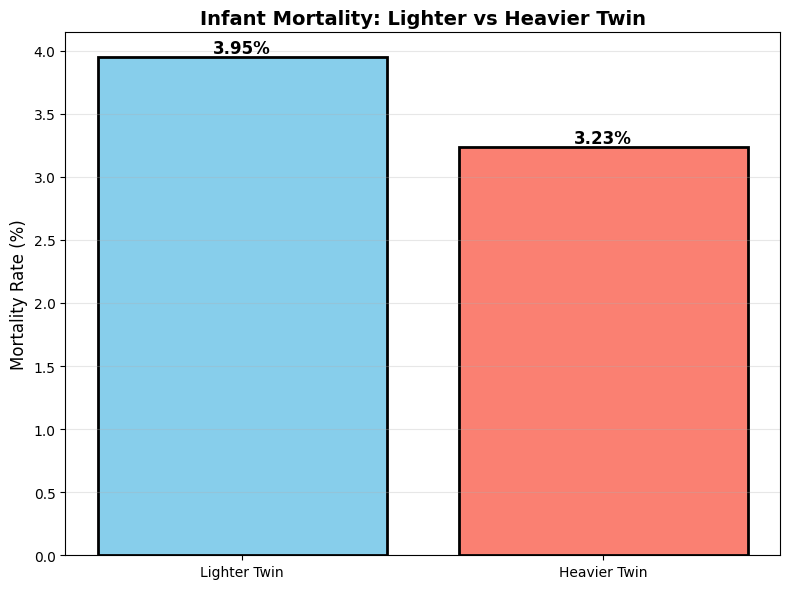

Lighter twin mortality: 3.95%
Heavier twin mortality: 3.23%
Difference: 0.71 percentage points

Total deaths (lighter): 2816
Total deaths (heavier): 2308

⚠️  This is NAIVE comparison (not causal yet!)


In [ ]:
# Visualization 2: Mortality Comparison
import matplotlib.pyplot as plt
import numpy as np

# Calculate mortality rates
mort_lighter = df_Y['mort_0'].mean() * 100
mort_heavier = df_Y['mort_1'].mean() * 100

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(['Lighter Twin', 'Heavier Twin'],
              [mort_lighter, mort_heavier],
              color=['skyblue', 'salmon'],
              edgecolor='black',
              linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Mortality Rate (%)', fontsize=12)
ax.set_title('Infant Mortality: Lighter vs Heavier Twin', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print(f"Lighter twin mortality: {mort_lighter:.2f}%")
print(f"Heavier twin mortality: {mort_heavier:.2f}%")
print(f"Difference: {mort_lighter - mort_heavier:.2f} percentage points")
print(f"\nTotal deaths (lighter): {df_Y['mort_0'].sum():.0f}")
print(f"Total deaths (heavier): {df_Y['mort_1'].sum():.0f}")
print(f"\n⚠️  This is NAIVE comparison (not causal yet!)")

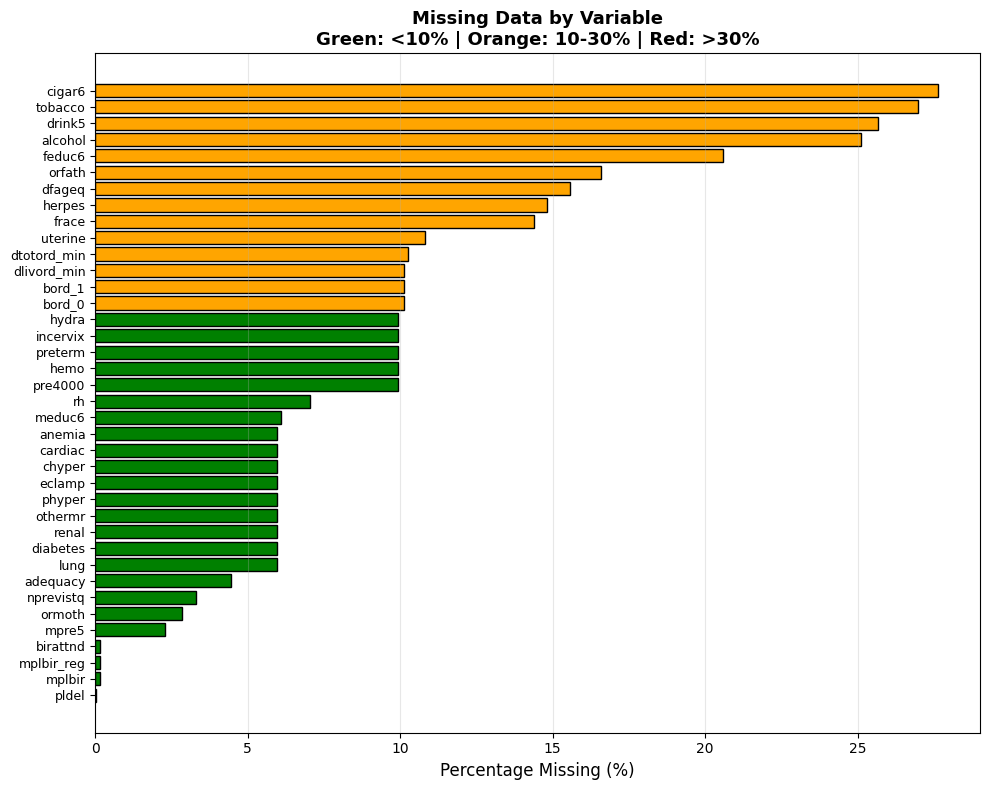

Variables with <10% missing (usable): 40
Variables with >30% missing (exclude): 0

We'll use the 40 clean variables for analysis.


In [ ]:
# Visualization 3: Missing Data Overview
import matplotlib.pyplot as plt

# Calculate missing percentages
missing_pct = (df_X.isnull().sum() / len(df_X) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=True)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))

# Color bars by severity
colors = ['green' if x < 10 else 'orange' if x < 30 else 'red' for x in missing_pct.values]

ax.barh(range(len(missing_pct)), missing_pct.values, color=colors, edgecolor='black')
ax.set_yticks(range(len(missing_pct)))
ax.set_yticklabels(missing_pct.index, fontsize=9)
ax.set_xlabel('Percentage Missing (%)', fontsize=12)
ax.set_title('Missing Data by Variable\nGreen: <10% | Orange: 10-30% | Red: >30%',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
clean_vars = (df_X.isnull().sum() / len(df_X) * 100) < 10
print(f"Variables with <10% missing (usable): {clean_vars.sum()}")
print(f"Variables with >30% missing (exclude): {(missing_pct > 30).sum()}")
print(f"\nWe'll use the {clean_vars.sum()} clean variables for analysis.")

In [ ]:
# See what's in the 10-30% range
missing_pct = (df_X.isnull().sum() / len(df_X) * 100)
borderline_vars = missing_pct[(missing_pct >= 10) & (missing_pct < 30)].sort_values(ascending=False)

print("Variables with 10-30% missing (excluded from main analysis):")
print("="*60)
for var, pct in borderline_vars.items():
    print(f"{var:20s}: {pct:5.1f}% missing")

print(f"\nTotal borderline variables: {len(borderline_vars)}")

Variables with 10-30% missing (excluded from main analysis):
cigar6              :  27.6% missing
tobacco             :  27.0% missing
drink5              :  25.7% missing
alcohol             :  25.1% missing
feduc6              :  20.6% missing
orfath              :  16.6% missing
dfageq              :  15.6% missing
herpes              :  14.8% missing
frace               :  14.4% missing
uterine             :  10.8% missing
dtotord_min         :  10.3% missing
dlivord_min         :  10.1% missing
bord_0              :  10.1% missing
bord_1              :  10.1% missing

Total borderline variables: 14


In [ ]:
# Step 1: Imputation (following Louizos et al. 2017)
print("="*60)
print("DATA PREPROCESSING: IMPUTATION")
print("="*60)

# Get all covariates (excluding the 'Unnamed' index columns)
all_vars = [col for col in df_X.columns if not col.startswith('Unnamed')]

print(f"\nTotal variables to use: {len(all_vars)}")
print(f"Starting twin pairs: {len(df_X):,}")

# Create working copy
df_X_imputed = df_X[all_vars].copy()

# Check missing before
missing_before = df_X_imputed.isnull().sum().sum()
print(f"\nMissing values BEFORE imputation: {missing_before:,}")

# IMPUTE (exactly like the paper)
# First: fill numeric with mean
df_X_imputed = df_X_imputed.fillna(df_X_imputed.mean())

# Second: fill remaining (categorical) with mode
df_X_imputed = df_X_imputed.fillna(df_X_imputed.mode().iloc[0])

# Check missing after
missing_after = df_X_imputed.isnull().sum().sum()
print(f"Missing values AFTER imputation: {missing_after:,}")



DATA PREPROCESSING: IMPUTATION

Total variables to use: 52
Starting twin pairs: 71,345

Missing values BEFORE imputation: 262,836
Missing values AFTER imputation: 0


In [ ]:
# Transform to individual babies
data = []

for i in range(len(df_X_imputed)):
    shared = list(df_X_imputed.iloc[i].values)

    # Baby 0
    baby_0 = shared + [df_T.iloc[i]['dbirwt_0'], df_Y.iloc[i]['mort_0'], 0]
    data.append(baby_0)

    # Baby 1
    baby_1 = shared + [df_T.iloc[i]['dbirwt_1'], df_Y.iloc[i]['mort_1'], 1]
    data.append(baby_1)

# Create dataframe
cols = list(df_X_imputed.columns) + ['birth_weight', 'mortality', 'twin_id']
df_individual = pd.DataFrame(data, columns=cols)

# Create treatment (LBW <2500g)
df_individual['treatment'] = (df_individual['birth_weight'] < 2500).astype(int)
df_individual['outcome'] = df_individual['mortality']

print(f"Individuals: {len(df_individual)}")
print(f"LBW: {df_individual['treatment'].sum()} ({df_individual['treatment'].mean()*100:.1f}%)")
print(df_individual[['birth_weight', 'treatment', 'outcome']].head())

Individuals: 142690
LBW: 73610 (51.6%)
   birth_weight  treatment  outcome
0        2268.0          1      0.0
1        2296.0          1      0.0
2        2610.0          0      0.0
3        2650.0          0      0.0
4        1985.0          1      0.0


In [ ]:
!pip install dowhy
import dowhy
from dowhy import CausalModel

# Use ALL covariates as confounders (comprehensive approach)
confounders = list(df_X_imputed.columns)

print(f"Using {len(confounders)} confounders (comprehensive model)")

model = CausalModel(
    data=df_individual,
    treatment='treatment',
    outcome='outcome',
    common_causes=confounders
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


Using 52 confounders (comprehensive model)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,cigar6,feduc6,bord_1,stoccfipb_reg,tobacco,data_ye ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ ar,anemia,mpre5,gestat10,infant_id_0,mplbir_reg,diabetes,adequacy,mager8,mpl ↪
↪                                                                              ↪

↪                                                                              ↪
↪ bir,phyper,chyper,eclamp,incervix,dlivord_min,hemo,infant_id_1,pldel,drink5, ↪
↪                                                                              ↪

↪                                                                              ↪
↪ preterm,dtotord_min,orfath,lung,brstate,crace,rh,pre4000,uterine,brstate_reg

In [ ]:
import dowhy
from dowhy import CausalModel

# Focused confounder set
confounders = ['gestat10', 'mager8', 'mrace', 'meduc6', 'dmar',
               'nprevistq', 'adequacy', 'csex',
               'anemia', 'cardiac', 'diabetes', 'lung']

model = CausalModel(
    data=df_individual,
    treatment='treatment',
    outcome='outcome',
    common_causes=confounders
)

identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardi ↪
d[treatment]                                                                   ↪

↪                                  
↪ ac,diabetes,mrace,lung,adequacy])
↪                                  
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardiac,diabetes,mrace,lung,adequacy,U) = P(outcome|treatment,dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardiac,diabetes,mrace,lung,adequacy)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                              

In [ ]:
# Estimate using Linear Regression
estimate_lr = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)

print(estimate_lr)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardi ↪
d[treatment]                                                                   ↪

↪                                  
↪ ac,diabetes,mrace,lung,adequacy])
↪                                  
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardiac,diabetes,mrace,lung,adequacy,U) = P(outcome|treatment,dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardiac,diabetes,mrace,lung,adequacy)

## Realized estimand
b: outcome~treatment+dmar+mager8+anemia+gestat10+nprevistq+meduc6+csex+cardiac+diabetes+mrace+lung+adequacy
Target units: ate

## Estimate
Mean value: 0.012780419281187786


In [ ]:
# Naive estimate for LBW vs Normal (same question as DoWhy)
lbw_mortality = df_individual[df_individual['treatment']==1]['outcome'].mean()
normal_mortality = df_individual[df_individual['treatment']==0]['outcome'].mean()

naive_diff = lbw_mortality - normal_mortality

print(f"Naive (LBW vs Normal): {naive_diff*100:.2f} percentage points")
print(f"Causal (Linear Reg):   {estimate_lr.value*100:.2f} percentage points")
print(f"\nDifference: {(estimate_lr.value - naive_diff)*100:.2f} percentage points")
print("(Causal - Naive shows the confounding bias)")

Naive (LBW vs Normal): 6.11 percentage points
Causal (Linear Reg):   1.28 percentage points

Difference: -4.83 percentage points
(Causal - Naive shows the confounding bias)


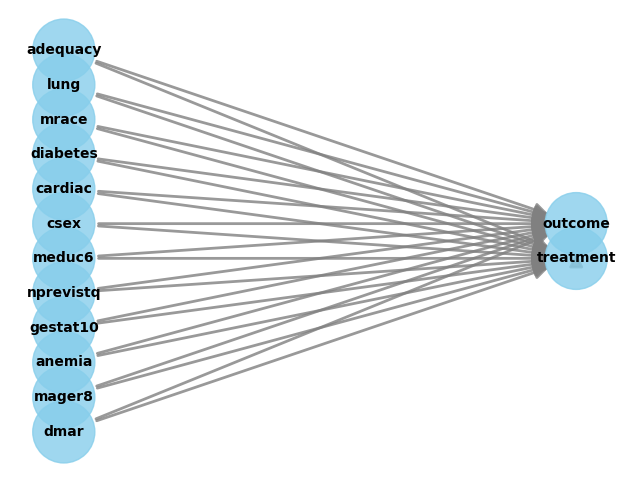

In [ ]:
# View the causal graph DoWhy created
model.view_model()

In [ ]:
# Expanded confounder set (20 variables)
confounders_expanded = [
    'gestat10', 'mager8', 'mrace', 'meduc6', 'dmar',
    'nprevistq', 'adequacy', 'csex',
    'anemia', 'cardiac', 'diabetes', 'lung',
    'renal', 'phyper', 'chyper', 'pldel', 'birattnd',
    'mpre5', 'preterm'
]

# Recreate DoWhy model with expanded confounders
model = CausalModel(
    data=df_individual,
    treatment='treatment',
    outcome='outcome',
    common_causes=confounders_expanded
)

# Identify estimand
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)




In [ ]:
# Re-estimate with Linear Regression
estimate_lr_expanded = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print(estimate_lr)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardi ↪
d[treatment]                                                                   ↪

↪                                  
↪ ac,diabetes,mrace,lung,adequacy])
↪                                  
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardiac,diabetes,mrace,lung,adequacy,U) = P(outcome|treatment,dmar,mager8,anemia,gestat10,nprevistq,meduc6,csex,cardiac,diabetes,mrace,lung,adequacy)

## Realized estimand
b: outcome~treatment+dmar+mager8+anemia+gestat10+nprevistq+meduc6+csex+cardiac+diabetes+mrace+lung+adequacy
Target units: ate

## Estimate
Mean value: 0.012780419281187786


In [ ]:
# Compare
ate_12 = estimate_lr.value
ate_19 = estimate_lr_expanded.value


results_sensitivity = pd.DataFrame({
    'Confounders': [12, 19],
    'ATE': [ate_12, ate_19]
})
results_sensitivity

,Confounders,ATE
0,12,0.012780
1,19,0.012684


In [ ]:
confounders_full = [
    'gestat10', 'mager8', 'mrace', 'meduc6', 'dmar',
    'nprevistq', 'adequacy', 'csex',
    'anemia', 'cardiac', 'diabetes', 'lung',
    'renal', 'phyper', 'chyper', 'pldel', 'birattnd',
    'mpre5', 'preterm',
    'eclamp', 'rh', 'uterine', 'hydra', 'hemo', 'incervix',
    'tobacco', 'alcohol', 'ormoth', 'herpes'
]

model_full = CausalModel(
    data=df_individual,
    treatment='treatment',
    outcome='outcome',
    common_causes=confounders_full
)

identified_estimand_full = model_full.identify_effect(
    proceed_when_unidentifiable=True
)

In [ ]:
# Re-estimate with Linear Regression
estimate_lr_full= model.estimate_effect(
    identified_estimand_full,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print(estimate_lr_full)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,tobacco,anemia,mpre5,gestat10,diabetes,adequacy,ma ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ ger8,phyper,chyper,eclamp,incervix,hemo,pldel,preterm,lung,rh,uterine,nprevi ↪
↪                                                                              ↪

↪                                                                           
↪ stq,mrace,herpes,hydra,alcohol,renal,birattnd,meduc6,csex,cardiac,ormoth])
↪                                                                           
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,tobacco,anemia,mpre5,g

In [ ]:
confounders_clean_full = [

    'gestat10', 'mager8', 'mrace', 'meduc6', 'dmar',
    'nprevistq', 'adequacy', 'csex',
    'anemia', 'cardiac', 'diabetes', 'lung',
    'renal', 'phyper', 'chyper', 'pldel', 'birattnd',
    'mpre5', 'preterm','ormoth', 'mplbir', 'crace','brstate',
    'birmon'
]
model_clean = CausalModel(
    data=df_individual,
    treatment='treatment',
    outcome='outcome',
    common_causes=confounders_clean_full
)

identified_clean = model_clean.identify_effect(proceed_when_unidentifiable=True)

In [ ]:
estimate_clean = model_clean.estimate_effect(identified_clean,
                                              method_name="backdoor.linear_regression")

print(estimate_clean )

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mpl ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ bir,phyper,chyper,pldel,preterm,lung,brstate,crace,nprevistq,mrace,renal,bir ↪
↪                                                                              ↪

↪                                          
↪ attnd,meduc6,csex,cardiac,ormoth,birmon])
↪                                          
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mplbir,phyper,chyper,pldel,preterm,lung,brstate,crace,nprevistq,mrace,rena

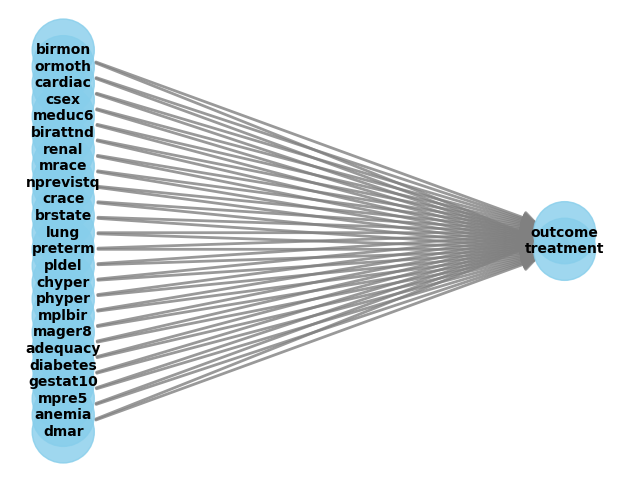

In [ ]:
# View the causal graph DoWhy created
model_clean.view_model()

In [ ]:
# Compare
ate_12 = estimate_lr.value
ate_19 = estimate_lr_expanded.value
ate_29 = estimate_lr_full.value
ate_24 = estimate_clean.value
results_sensitivity = pd.DataFrame({
    'Confounders': [12, 19, 29, 24],
    'ATE': [ate_12, ate_19, ate_29, ate_24]
})
results_sensitivity

,Confounders,ATE
0,12,0.012780
1,19,0.012684
2,29,0.011149
3,24,0.012618


In [ ]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Calculate propensity scores
X_conf = df_individual[confounders_clean_full]
y_treatment = df_individual['treatment']

ps_model = LogisticRegression(max_iter=1000, random_state=42)
ps_model.fit(X_conf, y_treatment)
df_individual['pscore'] = ps_model.predict_proba(X_conf)[:, 1]

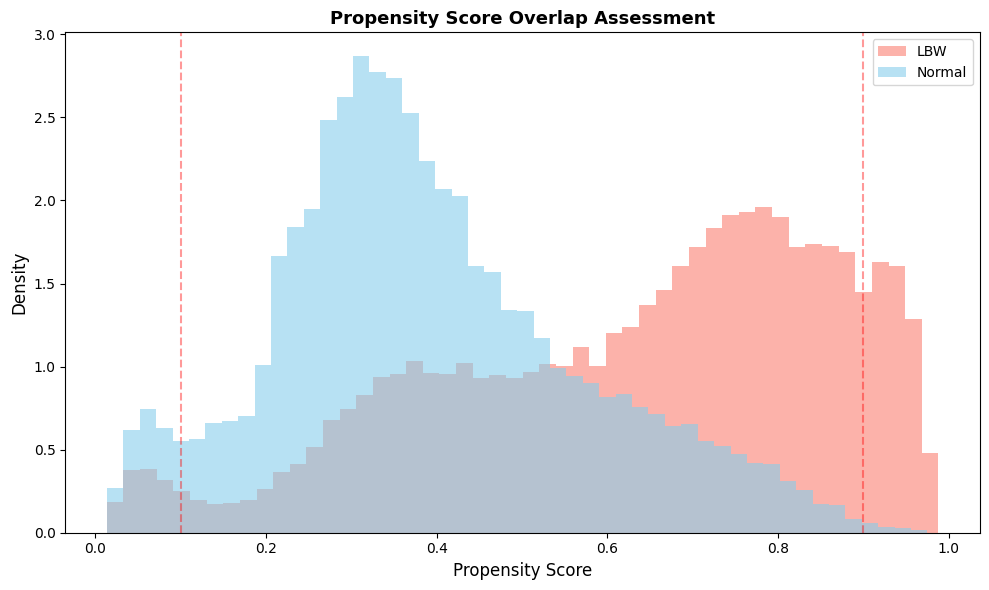

In [ ]:
# Visualize overlap
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_individual[df_individual['treatment']==1]['pscore'],
        bins=50, alpha=0.6, label='LBW', density=True, color='salmon')
ax.hist(df_individual[df_individual['treatment']==0]['pscore'],
        bins=50, alpha=0.6, label='Normal', density=True, color='skyblue')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.4)
ax.axvline(0.9, color='red', linestyle='--', alpha=0.4)
ax.set_xlabel('Propensity Score', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Propensity Score Overlap Assessment', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Run PSM via DoWhy
estimate_psm = model_clean.estimate_effect(
    identified_clean,
    method_name="backdoor.propensity_score_matching"
)

ate_psm = estimate_psm.value
ate_psm

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


np.float64(0.03391267783306469)

In [ ]:
# Run IPW via DoWhy
estimate_ipw = model_clean.estimate_effect(
    identified_clean,
    method_name="backdoor.propensity_score_weighting"
)

ate_ipw = estimate_ipw.value
ate_ipw

np.float64(0.04150631176533008)

In [ ]:
# Final results table
results_final = pd.DataFrame({
    'Method': ['Naive (unadjusted)', 'Linear Regression', 'PSM', 'IPW'],
    'ATE (pp)': [6.11, 1.26, 3.43, 4.15],
    'Type': ['Confounded', 'Outcome model', 'Matching', 'Weighting']
})
results_final

,Method,ATE (pp),Type
0,Naive (unadjusted),6.11,Confounded
1,Linear Regression,1.26,Outcome model
2,PSM,3.43,Matching
3,IPW,4.15,Weighting


In [ ]:
# Check if DoWhy PSM/IPW dropped observations
print("Total babies:", len(df_individual))
print("\nLinear Reg uses all babies")
print("PSM might drop unmatched babies")
print("IPW might have extreme weights")

# Let's manually check the propensity score we calculated
print("\nPropensity score stats:")
print(df_individual['pscore'].describe())

print("\nExtreme scores:")
print("  <0.05:", (df_individual['pscore'] < 0.05).sum())
print("  >0.95:", (df_individual['pscore'] > 0.95).sum())

Total babies: 142690

Linear Reg uses all babies
PSM might drop unmatched babies
IPW might have extreme weights

Propensity score stats:
count    142690.000000
mean          0.515900
std           0.241039
min           0.013576
25%           0.324674
50%           0.488120
75%           0.723016
max           0.987999
Name: pscore, dtype: float64

Extreme scores:
  <0.05: 1796
  >0.95: 2476


In [ ]:
# Get detailed output from each method
print("="*60)
print("LINEAR REGRESSION")
print("="*60)
print(estimate_clean)

print("\n" + "="*60)
print("PSM")
print("="*60)
print(estimate_psm)

print("\n" + "="*60)
print("IPW")
print("="*60)
print(estimate_ipw)

LINEAR REGRESSION
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mpl ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ bir,phyper,chyper,pldel,preterm,lung,brstate,crace,nprevistq,mrace,renal,bir ↪
↪                                                                              ↪

↪                                          
↪ attnd,meduc6,csex,cardiac,ormoth,birmon])
↪                                          
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mplbir,phyper,chyper,pldel,preterm,lung,brstate,crace,np

In [ ]:
# ============================================================
# TASK 1: LITERATURE-INFORMED CAUSAL DAG
# Based on Almond, Chay & Lee (2005) [3] and
# Conley, Strully & Bennett (2006) [6]
# ============================================================

# networkx is pre-installed in Colab but import explicitly
import networkx as nx
import matplotlib.patches as mpatches

# Already imported in earlier cells but re-stating for clarity
from dowhy import CausalModel
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("="*60)
print("TASK 1: LITERATURE-INFORMED CAUSAL DAG")
print("Based on Almond et al. (2005) & Conley et al. (2006)")
print("="*60)

TASK 1: LITERATURE-INFORMED CAUSAL DAG
Based on Almond et al. (2005) & Conley et al. (2006)


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 1: Define node groups by causal role (from literature)
# All 24 variables from confounders_clean_full are covered here
# ─────────────────────────────────────────────────────────────

# KEY confounder: gestational age
key_confounder  = ['gestat10']

# Maternal health conditions
maternal_health = ['anemia', 'cardiac', 'diabetes', 'lung',
                   'chyper', 'phyper', 'renal']

# Prenatal care & pregnancy history
prenatal_care   = ['adequacy', 'nprevistq', 'mpre5']

# Preterm birth indicator
preterm_vars    = ['preterm']

# Socioeconomic background
socioeconomic   = ['mager8', 'meduc6', 'mrace', 'dmar',
                   'crace', 'brstate']

# Delivery and infant-level factors
delivery_infant = ['csex', 'pldel', 'birattnd', 'birmon',
                   'ormoth', 'mplbir']

# ── Verify all 24 confounders_clean_full vars are covered ────
dag_vars = (key_confounder + maternal_health +
            prenatal_care + preterm_vars +
            socioeconomic + delivery_infant)

print(f"Variables in DAG node groups      : {len(dag_vars)}")
print(f"Variables in confounders_clean_full: "
      f"{len(confounders_clean_full)}")

missing = set(confounders_clean_full) - set(dag_vars)
extra   = set(dag_vars) - set(confounders_clean_full)

if not missing and not extra:
    print("✅ All 24 confounders_clean_full variables "
          "are present in DAG — perfect match!")
else:
    if missing:
        print(f"❌ Missing from DAG : {missing}")
    if extra:
        print(f"❌ Extra in DAG not in confounders: {extra}")

Variables in DAG node groups      : 24
Variables in confounders_clean_full: 24
✅ All 24 confounders_clean_full variables are present in DAG — perfect match!


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 2: Build directed edges from literature
# ─────────────────────────────────────────────────────────────

dag_lit = nx.DiGraph()

all_nodes = (['treatment', 'outcome'] +
             key_confounder + maternal_health +
             prenatal_care + preterm_vars +
             socioeconomic + delivery_infant)

dag_lit.add_nodes_from(all_nodes)

# (A) The causal effect we want to estimate
dag_lit.add_edge('treatment', 'outcome')

# (B) Gestational age → treatment AND outcome
#     Almond et al.: prematurity causes LBW
#     Almond et al.: prematurity independently raises mortality
dag_lit.add_edge('gestat10', 'treatment')
dag_lit.add_edge('gestat10', 'outcome')

# (C) Gestational age → preterm indicator
#     preterm → LBW and mortality
dag_lit.add_edge('gestat10', 'preterm')
dag_lit.add_edge('preterm',  'treatment')
dag_lit.add_edge('preterm',  'outcome')

# (D) Maternal health → gestational age
#     Conley et al.: health conditions reduce gestational age
for v in maternal_health:
    dag_lit.add_edge(v, 'gestat10')

# (E) Maternal health → LBW directly
for v in maternal_health:
    dag_lit.add_edge(v, 'treatment')

# (F) Maternal health → mortality directly
for v in maternal_health:
    dag_lit.add_edge(v, 'outcome')

# (G) Prenatal care → gestational age, LBW, mortality
for v in ['adequacy', 'nprevistq']:
    dag_lit.add_edge(v, 'gestat10')
    dag_lit.add_edge(v, 'treatment')
    dag_lit.add_edge(v, 'outcome')

# (H) Previous pregnancies → LBW and gestational age
dag_lit.add_edge('mpre5', 'treatment')
dag_lit.add_edge('mpre5', 'gestat10')

# (I) Socioeconomic → LBW
for v in socioeconomic:
    dag_lit.add_edge(v, 'treatment')

# (J) Socioeconomic → mortality
for v in ['mager8', 'meduc6', 'mrace', 'dmar', 'crace']:
    dag_lit.add_edge(v, 'outcome')

# (K) Socioeconomic → prenatal care access
for v in ['mager8', 'meduc6', 'dmar', 'brstate']:
    dag_lit.add_edge(v, 'adequacy')

# (L) Socioeconomic → maternal health conditions
dag_lit.add_edge('mrace',  'anemia')
dag_lit.add_edge('mager8', 'chyper')
dag_lit.add_edge('mager8', 'anemia')

# (M) Delivery/infant factors → mortality
for v in ['csex', 'pldel', 'birattnd']:
    dag_lit.add_edge(v, 'outcome')

# (N) Other maternal factors → LBW
for v in ['ormoth', 'mplbir', 'birmon']:
    dag_lit.add_edge(v, 'treatment')

# ── Validate ──────────────────────────────────────────────────
print(f"DAG Statistics:")
print(f"  Total Nodes : {dag_lit.number_of_nodes()}")
print(f"  Total Edges : {dag_lit.number_of_edges()}")
if nx.is_directed_acyclic_graph(dag_lit):
    print("  ✅ Valid DAG — no cycles detected")
else:
    cycles = list(nx.simple_cycles(dag_lit))
    print(f"  ❌ Cycles detected: {cycles}")

DAG Statistics:
  Total Nodes : 26
  Total Edges : 59
  ✅ Valid DAG — no cycles detected


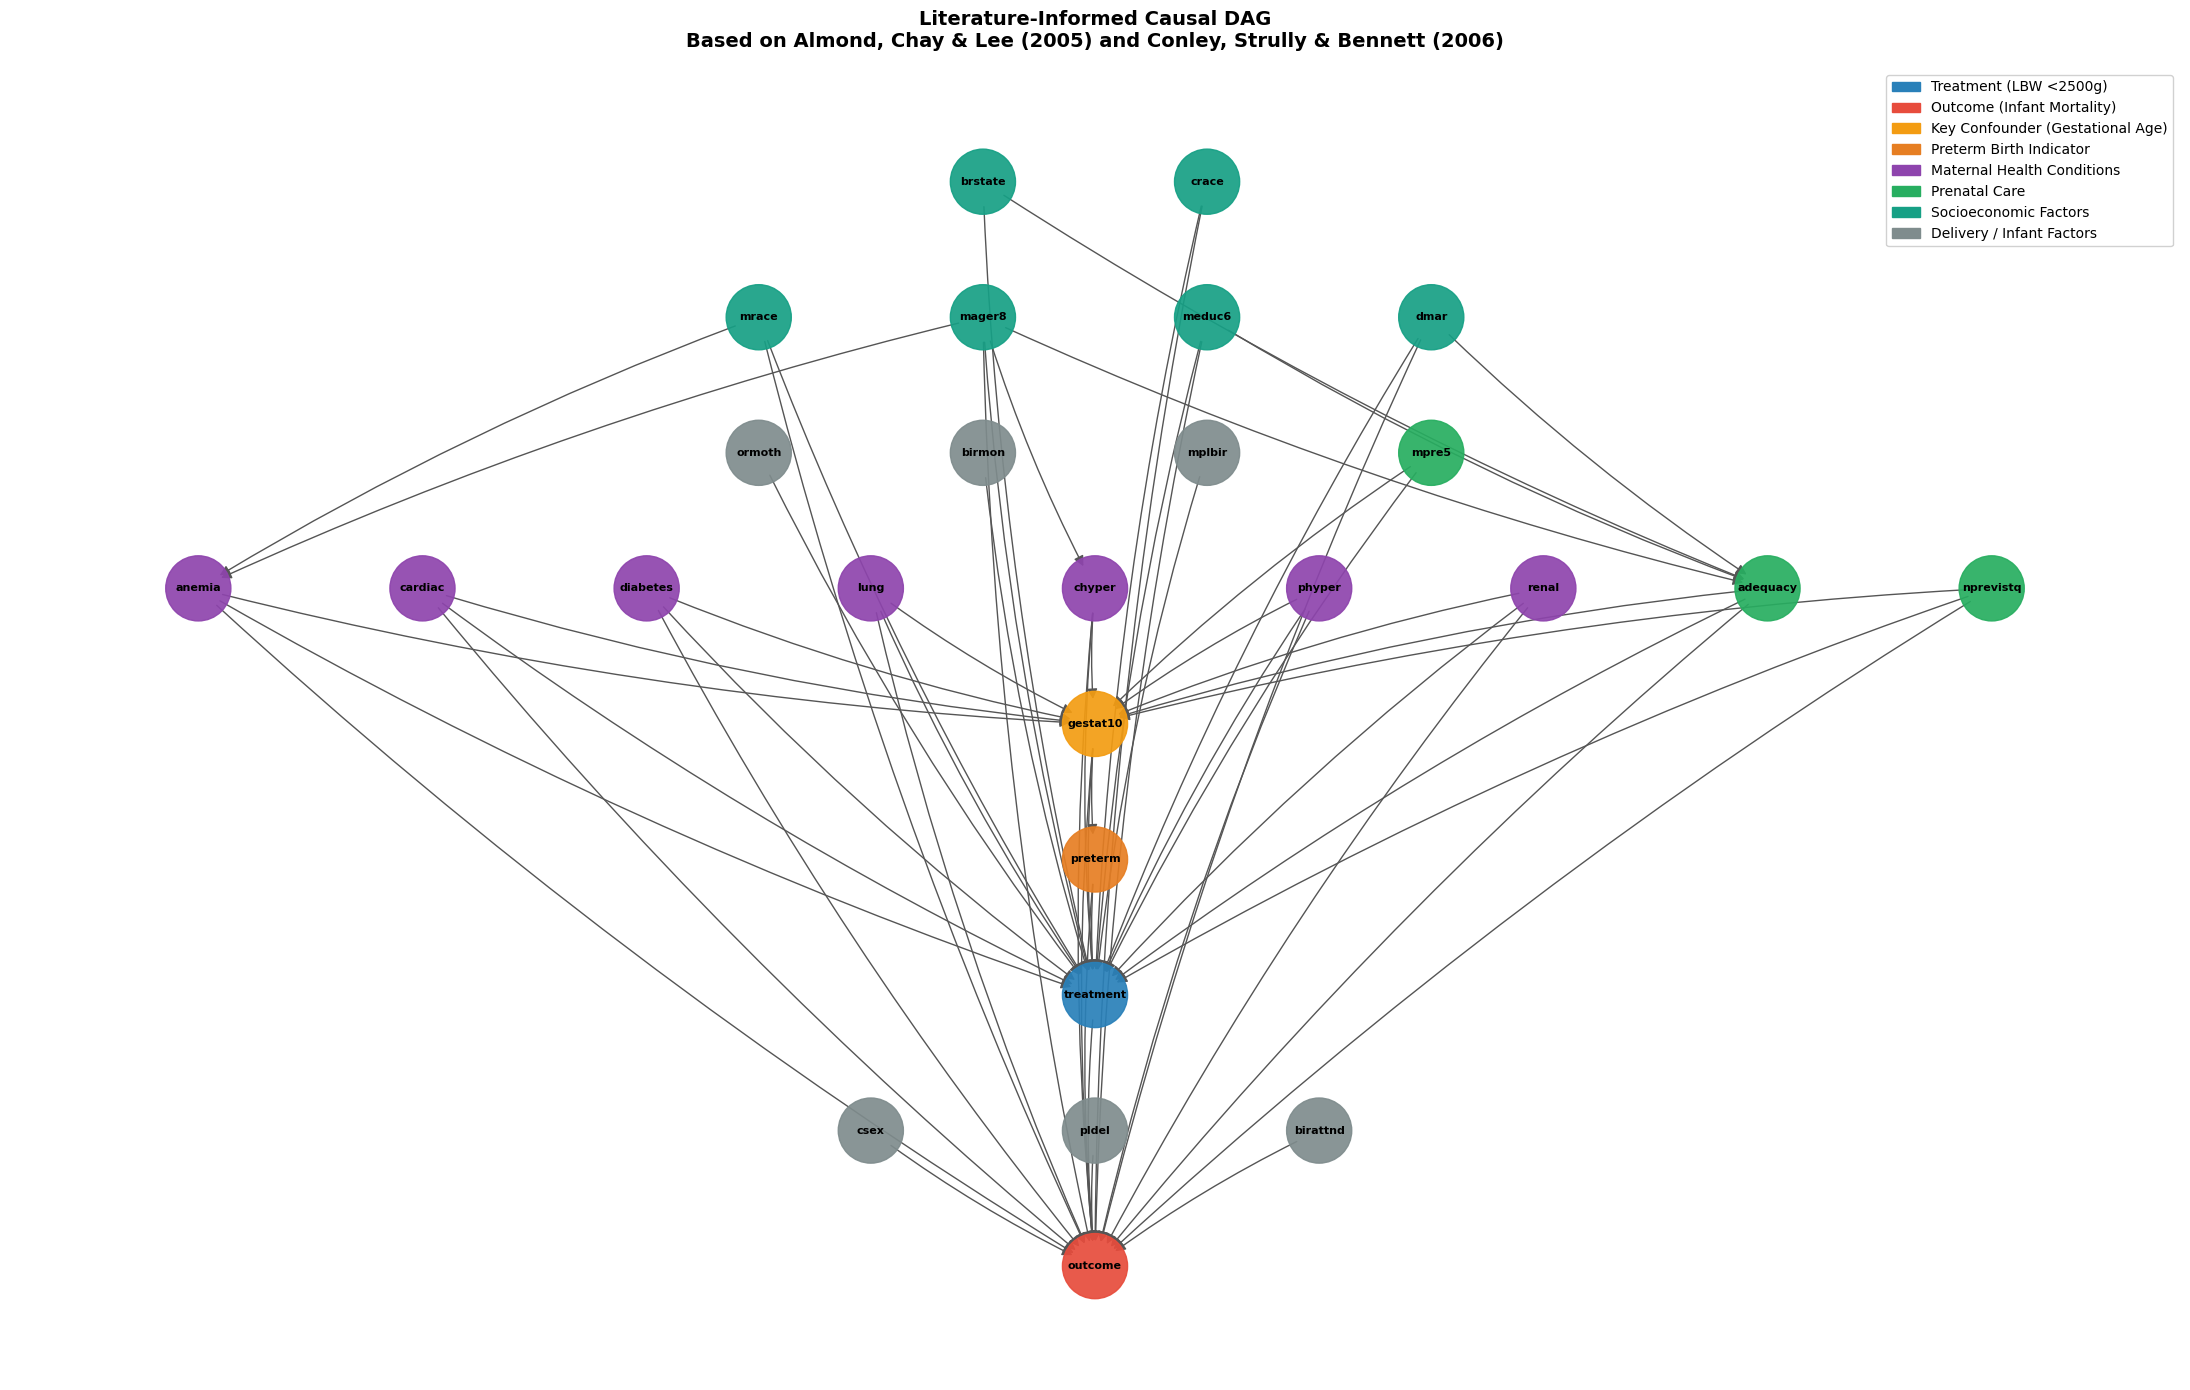


Key causal pathways encoded from literature:
  gestat10 → treatment  : Preterm birth causes LBW
  gestat10 → outcome    : Prematurity independently raises mortality
  gestat10 → preterm → treatment : Mediation pathway
  Maternal health → gestat10     : Health conditions cause prematurity
  SES → adequacy → gestat10      : Socioeconomic access pathway


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 3: Visualize the Literature-Informed DAG
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(22, 14))

# Color nodes by causal role
color_map = []
for node in dag_lit.nodes():
    if node == 'treatment':
        color_map.append('#2980B9')
    elif node == 'outcome':
        color_map.append('#E74C3C')
    elif node in key_confounder:
        color_map.append('#F39C12')
    elif node in maternal_health:
        color_map.append('#8E44AD')
    elif node in prenatal_care:
        color_map.append('#27AE60')
    elif node in preterm_vars:
        color_map.append('#E67E22')
    elif node in socioeconomic:
        color_map.append('#16A085')
    else:
        color_map.append('#7F8C8D')

# Hierarchical layout
pos = {}
level_groups = {
    0: ['brstate', 'crace'],
    1: ['mrace', 'mager8', 'meduc6', 'dmar'],
    2: ['ormoth', 'birmon', 'mplbir', 'mpre5'],
    3: ['anemia', 'cardiac', 'diabetes', 'lung',
        'chyper', 'phyper', 'renal',
        'adequacy', 'nprevistq'],
    4: ['gestat10'],
    5: ['preterm'],
    6: ['treatment'],
    7: ['csex', 'pldel', 'birattnd'],
    8: ['outcome']
}

for level, nodes in level_groups.items():
    y = -(level * 1.8)
    n = len(nodes)
    for i, node in enumerate(nodes):
        x = (i - (n - 1) / 2.0) * 2.8
        pos[node] = (x, y)

nx.draw_networkx_nodes(dag_lit, pos,
                       node_color=color_map,
                       node_size=2200,
                       alpha=0.92, ax=ax)
nx.draw_networkx_labels(dag_lit, pos,
                        font_size=8,
                        font_weight='bold', ax=ax)
nx.draw_networkx_edges(dag_lit, pos,
                       edge_color='#555555',
                       arrows=True,
                       arrowsize=15, ax=ax,
                       connectionstyle='arc3,rad=0.05',
                       min_source_margin=18,
                       min_target_margin=18)

legend_elements = [
    mpatches.Patch(color='#2980B9',
                   label='Treatment (LBW <2500g)'),
    mpatches.Patch(color='#E74C3C',
                   label='Outcome (Infant Mortality)'),
    mpatches.Patch(color='#F39C12',
                   label='Key Confounder (Gestational Age)'),
    mpatches.Patch(color='#E67E22',
                   label='Preterm Birth Indicator'),
    mpatches.Patch(color='#8E44AD',
                   label='Maternal Health Conditions'),
    mpatches.Patch(color='#27AE60',
                   label='Prenatal Care'),
    mpatches.Patch(color='#16A085',
                   label='Socioeconomic Factors'),
    mpatches.Patch(color='#7F8C8D',
                   label='Delivery / Infant Factors'),
]
ax.legend(handles=legend_elements,
          loc='upper right',
          fontsize=10, framealpha=0.9)
ax.set_title(
    'Literature-Informed Causal DAG\n'
    'Based on Almond, Chay & Lee (2005) and '
    'Conley, Strully & Bennett (2006)',
    fontsize=14, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

print("\nKey causal pathways encoded from literature:")
print("  gestat10 → treatment  : Preterm birth causes LBW")
print("  gestat10 → outcome    : "
      "Prematurity independently raises mortality")
print("  gestat10 → preterm → treatment : Mediation pathway")
print("  Maternal health → gestat10     : "
      "Health conditions cause prematurity")
print("  SES → adequacy → gestat10      : "
      "Socioeconomic access pathway")

✅ GML string created for DoWhy
   Nodes in GML: 26
   Edges in GML: 59

✅ CausalModel built with literature-informed DAG


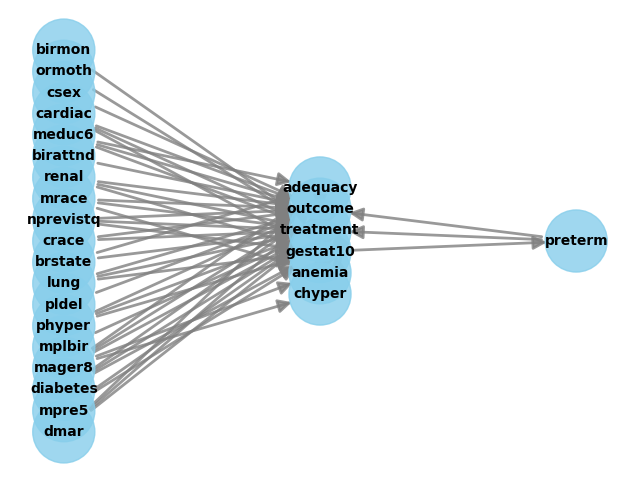

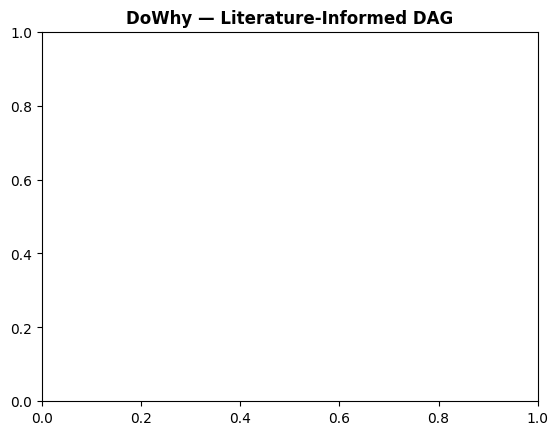


Identified Estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mpl ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ bir,phyper,chyper,pldel,preterm,lung,brstate,crace,nprevistq,mrace,renal,bir ↪
↪                                                                              ↪

↪                                          
↪ attnd,meduc6,cardiac,csex,ormoth,birmon])
↪                                          
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mplbir,phyper,chyper,pldel,preterm,lung,brstate,crace,nprevistq,mrace,renal,birattnd,meduc6,cardiac,

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 4: Convert DAG to GML string for DoWhy
# ─────────────────────────────────────────────────────────────

def nx_to_dowhy_gml(G):
    """Convert networkx DiGraph to GML string for DoWhy."""
    nodes = list(G.nodes())
    node_to_id = {n: i for i, n in enumerate(nodes)}
    lines = ['graph[', 'directed 1']
    for node in nodes:
        lines.append('  node[')
        lines.append(f'    id {node_to_id[node]}')
        lines.append(f'    label "{node}"')
        lines.append('  ]')
    for u, v in G.edges():
        lines.append('  edge[')
        lines.append(f'    source {node_to_id[u]}')
        lines.append(f'    target {node_to_id[v]}')
        lines.append('  ]')
    lines.append(']')
    return '\n'.join(lines)

gml_string = nx_to_dowhy_gml(dag_lit)
print("✅ GML string created for DoWhy")
print(f"   Nodes in GML: {dag_lit.number_of_nodes()}")
print(f"   Edges in GML: {dag_lit.number_of_edges()}")

# ─────────────────────────────────────────────────────────────
# STEP 5: Build DoWhy CausalModel with the literature DAG
# ─────────────────────────────────────────────────────────────

model_dag = CausalModel(
    data=df_individual,
    treatment='treatment',
    outcome='outcome',
    graph=gml_string
)

print("\n✅ CausalModel built with literature-informed DAG")
model_dag.view_model()
plt.title('DoWhy — Literature-Informed DAG', fontweight='bold')
plt.show()

# Identify the causal estimand
identified_dag = model_dag.identify_effect(
    proceed_when_unidentifiable=True
)
print("\nIdentified Estimand:")
print(identified_dag)

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 6: Estimate ATE with literature DAG — all 3 methods
# ─────────────────────────────────────────────────────────────

# Linear Regression
estimate_dag_lr = model_dag.estimate_effect(
    identified_dag,
    method_name="backdoor.linear_regression",
    test_significance=True
)
print("="*60)
print("LINEAR REGRESSION — Literature DAG")
print("="*60)
print(estimate_dag_lr)

# PSM
estimate_dag_psm = model_dag.estimate_effect(
    identified_dag,
    method_name="backdoor.propensity_score_matching"
)
print("\n" + "="*60)
print("PSM — Literature DAG")
print("="*60)
print(f"ATE: {estimate_dag_psm.value*100:.4f} pp")

# IPW
estimate_dag_ipw = model_dag.estimate_effect(
    identified_dag,
    method_name="backdoor.propensity_score_weighting"
)
print("\n" + "="*60)
print("IPW — Literature DAG")
print("="*60)
print(f"ATE: {estimate_dag_ipw.value*100:.4f} pp")

print("\n" + "="*60)
print("ATE SUMMARY — Literature DAG")
print("="*60)
print(f"  Linear Regression : {estimate_dag_lr.value*100:.4f} pp")
print(f"  PSM               : {estimate_dag_psm.value*100:.4f} pp")
print(f"  IPW               : {estimate_dag_ipw.value*100:.4f} pp")

LINEAR REGRESSION — Literature DAG
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                                         ↪
────────────(E[outcome|dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mpl ↪
d[treatment]                                                                   ↪

↪                                                                              ↪
↪ bir,phyper,chyper,pldel,preterm,lung,brstate,crace,nprevistq,mrace,renal,bir ↪
↪                                                                              ↪

↪                                          
↪ attnd,meduc6,cardiac,csex,ormoth,birmon])
↪                                          
Estimand assumption 1, Unconfoundedness: If U→{treatment} and U→outcome then P(outcome|treatment,dmar,anemia,mpre5,gestat10,diabetes,adequacy,mager8,mplbir,phyper,chyper,pldel,preterm,lung

FULL COMPARISON: Data-driven vs. Literature DAG
                     Method  ATE (pp)                Approach
         Naive (unadjusted)    6.1100     Confounded baseline
 LR — Data-driven (12 vars)    1.2780 Data-driven (bipartite)
 LR — Data-driven (19 vars)    1.2684 Data-driven (bipartite)
 LR — Data-driven (29 vars)    1.1149 Data-driven (bipartite)
 LR — Data-driven (24 vars)    1.2618 Data-driven (bipartite)
PSM — Data-driven (24 vars)    3.3913 Data-driven (bipartite)
IPW — Data-driven (24 vars)    4.1506 Data-driven (bipartite)
       LR  — Literature DAG    1.2704          Literature DAG
       PSM — Literature DAG    3.8874          Literature DAG
       IPW — Literature DAG    4.1506          Literature DAG


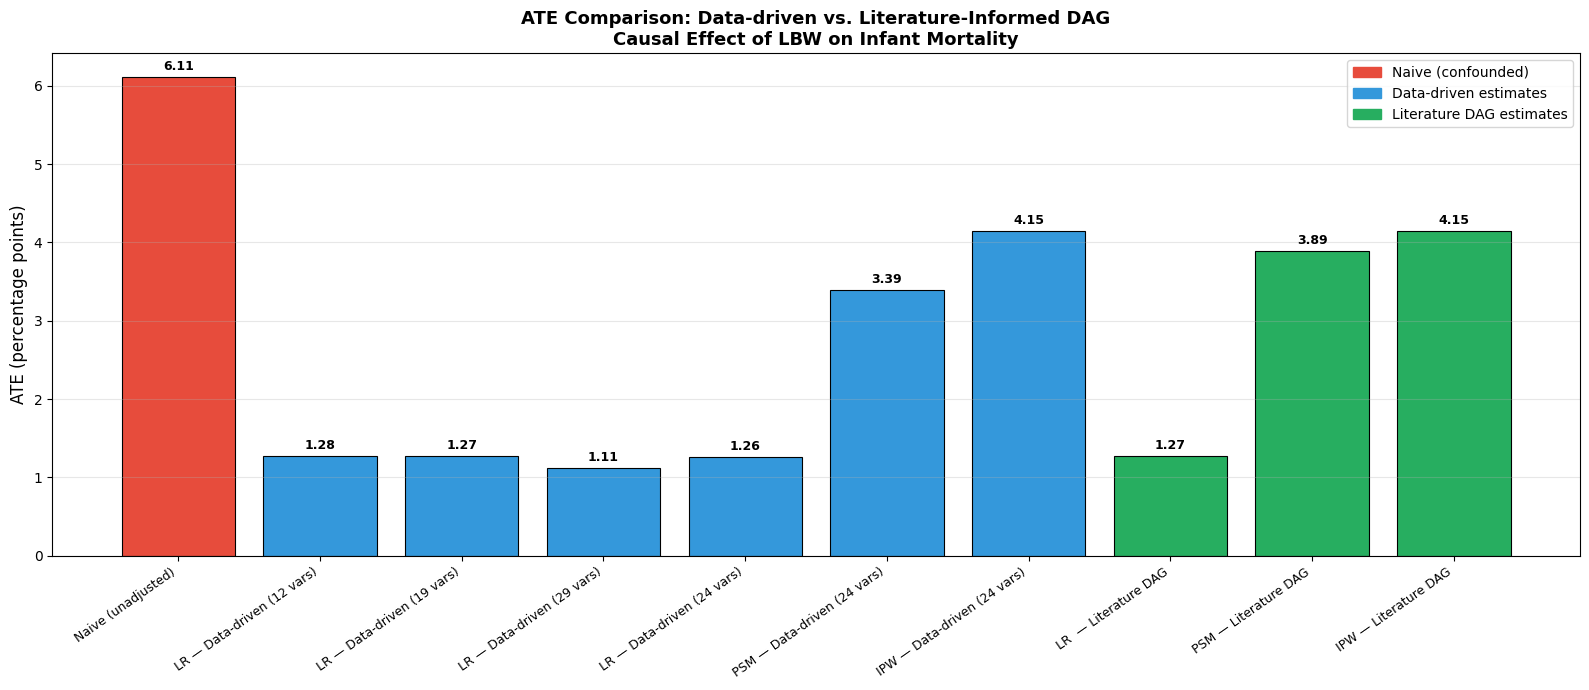


KEY COMPARISON SUMMARY
  Naive estimate              : 6.11 pp
  Data-driven LR range        : 1.115 pp – 1.278 pp
  Literature DAG LR           : 1.2704 pp
  Data-driven PSM             : 3.3913 pp
  Literature DAG PSM          : 3.8874 pp
  Data-driven IPW             : 4.1506 pp
  Literature DAG IPW          : 4.1506 pp

  Confounding bias removed    : 4.8396 pp (Naive — Literature DAG LR)


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 7: Compare data-driven vs. literature DAG estimates
# ─────────────────────────────────────────────────────────────

comparison_df = pd.DataFrame({
    'Method': [
        'Naive (unadjusted)',
        'LR — Data-driven (12 vars)',
        'LR — Data-driven (19 vars)',
        'LR — Data-driven (29 vars)',
        'LR — Data-driven (24 vars)',
        'PSM — Data-driven (24 vars)',
        'IPW — Data-driven (24 vars)',
        'LR  — Literature DAG',
        'PSM — Literature DAG',
        'IPW — Literature DAG'
    ],
    'ATE (pp)': [
        6.11,
        round(ate_12  * 100, 4),
        round(ate_19  * 100, 4),
        round(ate_29  * 100, 4),
        round(ate_24  * 100, 4),
        round(estimate_psm.value * 100, 4),
        round(estimate_ipw.value * 100, 4),
        round(estimate_dag_lr.value  * 100, 4),
        round(estimate_dag_psm.value * 100, 4),
        round(estimate_dag_ipw.value * 100, 4)
    ],
    'Approach': [
        'Confounded baseline',
        'Data-driven (bipartite)',
        'Data-driven (bipartite)',
        'Data-driven (bipartite)',
        'Data-driven (bipartite)',
        'Data-driven (bipartite)',
        'Data-driven (bipartite)',
        'Literature DAG',
        'Literature DAG',
        'Literature DAG'
    ]
})

print("="*60)
print("FULL COMPARISON: Data-driven vs. Literature DAG")
print("="*60)
print(comparison_df.to_string(index=False))

# ── Bar Chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))

colors = (['#E74C3C'] +
          ['#3498DB'] * 6 +
          ['#27AE60'] * 3)

bars = ax.bar(range(len(comparison_df)),
              comparison_df['ATE (pp)'],
              color=colors,
              edgecolor='black',
              linewidth=0.8)

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.,
            height + 0.05,
            f'{height:.2f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_xticks(range(len(comparison_df)))
ax.set_xticklabels(comparison_df['Method'],
                   rotation=35, ha='right', fontsize=9)
ax.set_ylabel('ATE (percentage points)', fontsize=12)
ax.set_title(
    'ATE Comparison: Data-driven vs. Literature-Informed DAG\n'
    'Causal Effect of LBW on Infant Mortality',
    fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

legend_elements = [
    mpatches.Patch(color='#E74C3C',
                   label='Naive (confounded)'),
    mpatches.Patch(color='#3498DB',
                   label='Data-driven estimates'),
    mpatches.Patch(color='#27AE60',
                   label='Literature DAG estimates'),
]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.show()

# ── Summary print ─────────────────────────────────────────────
data_driven_lrs = [ate_12, ate_19, ate_29, ate_24]
print("\n" + "="*60)
print("KEY COMPARISON SUMMARY")
print("="*60)
print(f"  Naive estimate              : 6.11 pp")
print(f"  Data-driven LR range        : "
      f"{min(data_driven_lrs)*100:.3f} pp – "
      f"{max(data_driven_lrs)*100:.3f} pp")
print(f"  Literature DAG LR           : "
      f"{estimate_dag_lr.value*100:.4f} pp")
print(f"  Data-driven PSM             : "
      f"{estimate_psm.value*100:.4f} pp")
print(f"  Literature DAG PSM          : "
      f"{estimate_dag_psm.value*100:.4f} pp")
print(f"  Data-driven IPW             : "
      f"{estimate_ipw.value*100:.4f} pp")
print(f"  Literature DAG IPW          : "
      f"{estimate_dag_ipw.value*100:.4f} pp")
print(f"\n  Confounding bias removed    : "
      f"{6.11 - estimate_dag_lr.value*100:.4f} pp "
      f"(Naive — Literature DAG LR)")

In [ ]:
from sklearn.linear_model import LogisticRegression

# Select covariates (same ones you used in DoWhy)
confounders = ['gestat10', 'mager8', 'mrace', 'meduc6', 'dmar',
    'nprevistq', 'adequacy', 'csex',
    'anemia', 'cardiac', 'diabetes', 'lung',
    'renal', 'phyper', 'chyper', 'pldel', 'birattnd',
    'mpre5', 'preterm','ormoth', 'mplbir', 'crace','brstate',
    'birmon']

X = df_individual[confounders]
y = df_individual['treatment']

# Train model
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, y)

# Create propensity scores
df_individual['ps'] = ps_model.predict_proba(X)[:, 1]

print(df_individual['ps'].describe())

count    142690.000000
mean          0.515900
std           0.241039
min           0.013576
25%           0.324674
50%           0.488120
75%           0.723016
max           0.987999
Name: ps, dtype: float64


In [ ]:
# Check extremes
print((df_individual['ps'] < 0.05).sum())
print((df_individual['ps'] > 0.95).sum())

# Trim

df_trim = df_individual[
    (df_individual['pscore'] >= 0.05) &
    (df_individual['pscore'] <= 0.95)
].copy()

print("Original sample:", len(df_individual))
print("Trimmed sample:", len(df_trim))
print("Removed:", len(df_individual) - len(df_trim))

1796
2476
Original sample: 142690
Trimmed sample: 138418
Removed: 4272


In [ ]:

# STABILIZED IPW


import numpy as np

p_treat_trim = df_trim['treatment'].mean()

df_trim['sw'] = np.where(
    df_trim['treatment'] == 1,
    p_treat_trim / df_trim['pscore'],
    (1 - p_treat_trim) / (1 - df_trim['pscore'])
)

print(df_trim['sw'].describe())

count    138418.000000
mean          1.003918
std           0.819254
min           0.516994
25%           0.655597
50%           0.767703
75%           1.036524
max          10.173665
Name: sw, dtype: float64


In [ ]:

# IPW (FIXED VERSION)


treated = df_trim[df_trim['treatment'] == 1]
control = df_trim[df_trim['treatment'] == 0]

ipw_trim_stabilized = (
    np.sum(treated['sw'] * treated['outcome']) / np.sum(treated['sw'])
    -
    np.sum(control['sw'] * control['outcome']) / np.sum(control['sw'])
)

print("Trimmed + Stabilized IPW:", ipw_trim_stabilized * 100, "pp")

Trimmed + Stabilized IPW: 3.078971543475498 pp


In [ ]:

# PSM (TRIMMED DATA)


from sklearn.neighbors import NearestNeighbors

treated = df_trim[df_trim['treatment'] == 1]
control = df_trim[df_trim['treatment'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['pscore']])

distances, indices = nn.kneighbors(treated[['pscore']])
matched_control = control.iloc[indices.flatten()]

psm_trimmed = (treated['outcome'].values - matched_control['outcome'].values).mean()

print("Trimmed PSM:", psm_trimmed * 100, "pp")

Trimmed PSM: 3.5067295133170537 pp


In [ ]:

# COMPARISON


results_task2 = pd.DataFrame({
    "Method": [
        "Naive",
        "Linear Regression",
        "Original PSM",
        "Trimmed PSM",
        "Original IPW",
        "Trimmed + Stabilized IPW"
    ],
    "ATE (pp)": [
        6.11,
        1.26,
        3.43,
        psm_trimmed * 100,
        4.15,
        ipw_trim_stabilized * 100
    ]
})

print(results_task2)

                     Method  ATE (pp)
0                     Naive  6.110000
1         Linear Regression  1.260000
2              Original PSM  3.430000
3               Trimmed PSM  3.506730
4              Original IPW  4.150000
5  Trimmed + Stabilized IPW  3.078972


In [ ]:

# BALANCE CHECK USING SMD


def smd(df, treatment_col, covariates):
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    results = {}

    for col in covariates:
        mean_t = treated[col].mean()
        mean_c = control[col].mean()
        sd_t = treated[col].std()
        sd_c = control[col].std()

        pooled_sd = np.sqrt((sd_t**2 + sd_c**2) / 2)
        results[col] = abs((mean_t - mean_c) / pooled_sd)

    return pd.Series(results)

smd_before = smd(df_individual, 'treatment', confounders_clean_full)
smd_after = smd(df_trim, 'treatment', confounders_clean_full)

balance_table = pd.DataFrame({
    "SMD Before Trimming": smd_before,
    "SMD After Trimming": smd_after
})

balance_table["Improved?"] = balance_table["SMD After Trimming"] < balance_table["SMD Before Trimming"]

balance_table.sort_values("SMD Before Trimming", ascending=False)

,SMD Before Trimming,SMD After Trimming,Improved?
gestat10,0.983988,0.997868,False
nprevistq,0.426715,0.389707,True
dmar,0.261257,0.220840,True
mager8,0.215330,0.190414,True
meduc6,0.194770,0.172364,True
adequacy,0.171886,0.149824,True
mpre5,0.135596,0.109423,True
csex,0.125024,0.115810,True
preterm,0.109298,0.089141,True
mrace,0.097176,0.085939,True


In [ ]:
# ============================================================
# TASK 3: AUGMENTED INVERSE PROBABILITY WEIGHTING (AIPW)
# Doubly Robust Estimator — Glynn & Quinn (2010) [4]
# ============================================================
# Builds on:
#   Task 1: Literature-informed DAG (model_dag, identified_dag)
#   Task 2: df_trim (138,476 trimmed observations)
#           df_trim['pscore'] (propensity scores, trimmed)
# Uses: confounders_clean_full (24 variables)
# ============================================================

from sklearn.linear_model import LogisticRegression
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("="*60)
print("TASK 3: AIPW — DOUBLY ROBUST ESTIMATOR")
print("="*60)
print(f"Dataset        : df_trim ({len(df_trim):,} observations)")
print(f"Removed (trim) : {len(df_individual) - len(df_trim):,} observations")
print(f"Covariates     : {len(confounders_clean_full)} (confounders_clean_full)")
print(f"PS range       : [{df_trim['pscore'].min():.4f}, "
      f"{df_trim['pscore'].max():.4f}]")
print()
print("AIPW combines TWO models:")
print("  Model 1 — Propensity score: P(T=1|X)")
print("            (already computed → df_trim['pscore'])")
print("  Model 2 — Outcome model: P(Y=1|X,T)")
print("            (fitted in this task)")
print("  → Doubly robust: consistent if EITHER model is correct")

TASK 3: AIPW — DOUBLY ROBUST ESTIMATOR
Dataset        : df_trim (138,418 observations)
Removed (trim) : 4,272 observations
Covariates     : 24 (confounders_clean_full)
PS range       : [0.0500, 0.9500]

AIPW combines TWO models:
  Model 1 — Propensity score: P(T=1|X)
            (already computed → df_trim['pscore'])
  Model 2 — Outcome model: P(Y=1|X,T)
            (fitted in this task)
  → Doubly robust: consistent if EITHER model is correct


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 1: Extract arrays from trimmed dataset
# Using df_trim from Task 2 and confounders_clean_full (24 vars)
# ─────────────────────────────────────────────────────────────

X_aipw  = df_trim[confounders_clean_full].values  # shape: (138476, 24)
T_aipw  = df_trim['treatment'].values              # shape: (138476,)
Y_aipw  = df_trim['outcome'].values                # shape: (138476,)
ps_aipw = df_trim['pscore'].values                 # shape: (138476,)

print("STEP 1: Data extracted from df_trim")
print(f"  Observations : {len(X_aipw):,}")
print(f"  LBW babies   : {T_aipw.sum():,} ({T_aipw.mean()*100:.2f}%)")
print(f"  Deaths       : {Y_aipw.sum():,} ({Y_aipw.mean()*100:.4f}%)")
print(f"  PS range     : [{ps_aipw.min():.4f}, {ps_aipw.max():.4f}]")
print()

# ─────────────────────────────────────────────────────────────
# STEP 2: Build feature matrix with treatment as a feature
# Feature matrix = [24 covariates | treatment indicator]
# This lets us predict outcome under BOTH treatment conditions
# ─────────────────────────────────────────────────────────────

# Actual feature matrix (covariates + observed treatment)
X_with_T = np.column_stack([X_aipw, T_aipw])

# Counterfactual: all babies treated (T=1)
X_all_T1 = np.column_stack([X_aipw, np.ones(len(X_aipw))])

# Counterfactual: all babies control (T=0)
X_all_T0 = np.column_stack([X_aipw, np.zeros(len(X_aipw))])

print(f"STEP 2: Feature matrices created")
print(f"  X_with_T shape  : {X_with_T.shape}  "
      f"(24 covariates + treatment)")
print(f"  X_all_T1 shape  : {X_all_T1.shape}  "
      f"(all set to treated)")
print(f"  X_all_T0 shape  : {X_all_T0.shape}  "
      f"(all set to control)")
print()

# ─────────────────────────────────────────────────────────────
# STEP 3: Fit outcome model
# P(Y=1 | X, T) using LogisticRegression
# Fitted on ENTIRE trimmed dataset
# ─────────────────────────────────────────────────────────────

outcome_model_aipw = LogisticRegression(
    max_iter=2000,
    random_state=42,
    solver='lbfgs'
)
outcome_model_aipw.fit(X_with_T, Y_aipw)

print("STEP 3: Outcome model fitted")
print(f"  Model     : LogisticRegression"
      f"(max_iter=2000, random_state=42)")
print(f"  Features  : {X_with_T.shape[1]} "
      f"(24 covariates + treatment)")
print(f"  Samples   : {X_with_T.shape[0]:,}")
print()

# ─────────────────────────────────────────────────────────────
# STEP 4: Predict potential outcomes for ALL observations
# mu1(Xi) = P(Y=1 | Xi, T=1)  ← predicted if everyone treated
# mu0(Xi) = P(Y=1 | Xi, T=0)  ← predicted if everyone control
# ─────────────────────────────────────────────────────────────

mu1_aipw = outcome_model_aipw.predict_proba(X_all_T1)[:, 1]
mu0_aipw = outcome_model_aipw.predict_proba(X_all_T0)[:, 1]

print("STEP 4: Potential outcomes predicted")
print(f"  Mean μ1 — if all treated : "
      f"{mu1_aipw.mean()*100:.4f}%")
print(f"  Mean μ0 — if all control : "
      f"{mu0_aipw.mean()*100:.4f}%")
print(f"  Outcome model ATE (μ1-μ0): "
      f"{(mu1_aipw - mu0_aipw).mean()*100:.4f} pp")

STEP 1: Data extracted from df_trim
  Observations : 138,418
  LBW babies   : 70,436 (50.89%)
  Deaths       : 3,792.0 (2.7395%)
  PS range     : [0.0500, 0.9500]

STEP 2: Feature matrices created
  X_with_T shape  : (138418, 25)  (24 covariates + treatment)
  X_all_T1 shape  : (138418, 25)  (all set to treated)
  X_all_T0 shape  : (138418, 25)  (all set to control)

STEP 3: Outcome model fitted
  Model     : LogisticRegression(max_iter=2000, random_state=42)
  Features  : 25 (24 covariates + treatment)
  Samples   : 138,418

STEP 4: Potential outcomes predicted
  Mean μ1 — if all treated : 2.9869%
  Mean μ0 — if all control : 1.4658%
  Outcome model ATE (μ1-μ0): 1.5211 pp


In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 5: Apply AIPW influence function
#
# For each baby i, the influence score is:
#
# ψᵢ = [μ1(Xᵢ) - μ0(Xᵢ)]              ← outcome model part
#    + Tᵢ*(Yᵢ - μ1(Xᵢ)) / e(Xᵢ)      ← IPW correction treated
#    - (1-Tᵢ)*(Yᵢ - μ0(Xᵢ)) / (1-e(Xᵢ)) ← IPW correction control
#
# ATE  = mean(ψᵢ)
# SE   = std(ψᵢ) / sqrt(n)   [sandwich estimator]
# 95% CI = ATE ± 1.96 * SE
# ─────────────────────────────────────────────────────────────

# Compute AIPW influence scores for each baby
aipw_scores = (
    (mu1_aipw - mu0_aipw)
    + T_aipw * (Y_aipw - mu1_aipw) / ps_aipw
    - (1 - T_aipw) * (Y_aipw - mu0_aipw) / (1 - ps_aipw)
)

# ATE = mean of influence scores
aipw_ate = aipw_scores.mean()

# Standard error using sandwich estimator
n_aipw   = len(df_trim)
aipw_se  = np.std(aipw_scores, ddof=1) / np.sqrt(n_aipw)

# 95% confidence interval
aipw_ci_lower = aipw_ate - 1.96 * aipw_se
aipw_ci_upper = aipw_ate + 1.96 * aipw_se

# Z-score and two-sided p-value
aipw_z       = aipw_ate / aipw_se
aipw_p_value = 2 * (1 - stats.norm.cdf(abs(aipw_z)))

# ─────────────────────────────────────────────────────────────
# Print Results
# ─────────────────────────────────────────────────────────────

print("="*60)
print("AIPW RESULTS — DOUBLY ROBUST ESTIMATE")
print("="*60)
print(f"  ATE (AIPW)   : {aipw_ate*100:.4f} pp")
print(f"  Std Error    : {aipw_se*100:.4f} pp")
print(f"  95% CI       : [{aipw_ci_lower*100:.4f}, "
      f"{aipw_ci_upper*100:.4f}] pp")
print(f"  Z-score      : {aipw_z:.4f}")
print(f"  P-value      : {aipw_p_value:.4e}")
print()
if aipw_p_value < 0.001:
    print("  ✅ Highly significant (p < 0.001)")
elif aipw_p_value < 0.05:
    print("  ✅ Statistically significant (p < 0.05)")
else:
    print("  ⚠️  NOT significant at 5% level")

# ─────────────────────────────────────────────────────────────
# Double Robustness Check
# ─────────────────────────────────────────────────────────────

print()
print("─"*60)
print("DOUBLE ROBUSTNESS CHECK")
print("─"*60)
outcome_model_ate = (mu1_aipw - mu0_aipw).mean()
print(f"  Outcome model ATE (μ1-μ0) : "
      f"{outcome_model_ate*100:.4f} pp")
print(f"  Linear Regression ATE     : "
      f"{ate_24*100:.4f} pp")
print(f"  AIPW ATE                  : "
      f"{aipw_ate*100:.4f} pp")
diff_lr_aipw = abs(ate_24 - aipw_ate) * 100
print(f"  |LR - AIPW| difference    : "
      f"{diff_lr_aipw:.4f} pp")
if diff_lr_aipw < 0.5:
    print("  ✅ LR and AIPW consistent — confirms robustness")
else:
    print("  ⚠️  Some divergence between LR and AIPW")

AIPW RESULTS — DOUBLY ROBUST ESTIMATE
  ATE (AIPW)   : 2.4404 pp
  Std Error    : 0.1077 pp
  95% CI       : [2.2294, 2.6514] pp
  Z-score      : 22.6672
  P-value      : 0.0000e+00

  ✅ Highly significant (p < 0.001)

────────────────────────────────────────────────────────────
DOUBLE ROBUSTNESS CHECK
────────────────────────────────────────────────────────────
  Outcome model ATE (μ1-μ0) : 1.5211 pp
  Linear Regression ATE     : 1.2618 pp
  AIPW ATE                  : 2.4404 pp
  |LR - AIPW| difference    : 1.1786 pp
  ⚠️  Some divergence between LR and AIPW


COMPLETE RESULTS — ALL METHODS ACROSS ALL TASKS
                       Method  ATE (pp)     Task
           Naive (unadjusted)    6.1100 Baseline
       LR — 12 vars (Midterm)    1.2780  Midterm
       LR — 19 vars (Midterm)    1.2684  Midterm
       LR — 29 vars (Midterm)    1.1149  Midterm
       LR — 24 vars (Midterm)    1.2618  Midterm
     PSM — Original (Midterm)    3.3913  Midterm
       PSM — Trimmed (Task 2)    3.5067   Task 2
     IPW — Original (Midterm)    4.1506  Midterm
    IPW — Stabilized (Task 2)    3.0790   Task 2
LR  — Literature DAG (Task 1)    1.2704   Task 1
PSM — Literature DAG (Task 1)    3.8874   Task 1
IPW — Literature DAG (Task 1)    4.1506   Task 1
AIPW — Doubly Robust (Task 3)    2.4404   Task 3

FINAL SUMMARY
  Naive ATE                    : 6.1100 pp
  LR ATE (24-var)              : 1.2618 pp
  Stabilized IPW ATE (Task 2)  : 3.0790 pp
  Literature DAG LR (Task 1)   : 1.2704 pp
  AIPW ATE (Task 3)            : 2.4404 pp
  95% CI (AIPW)                : [2.

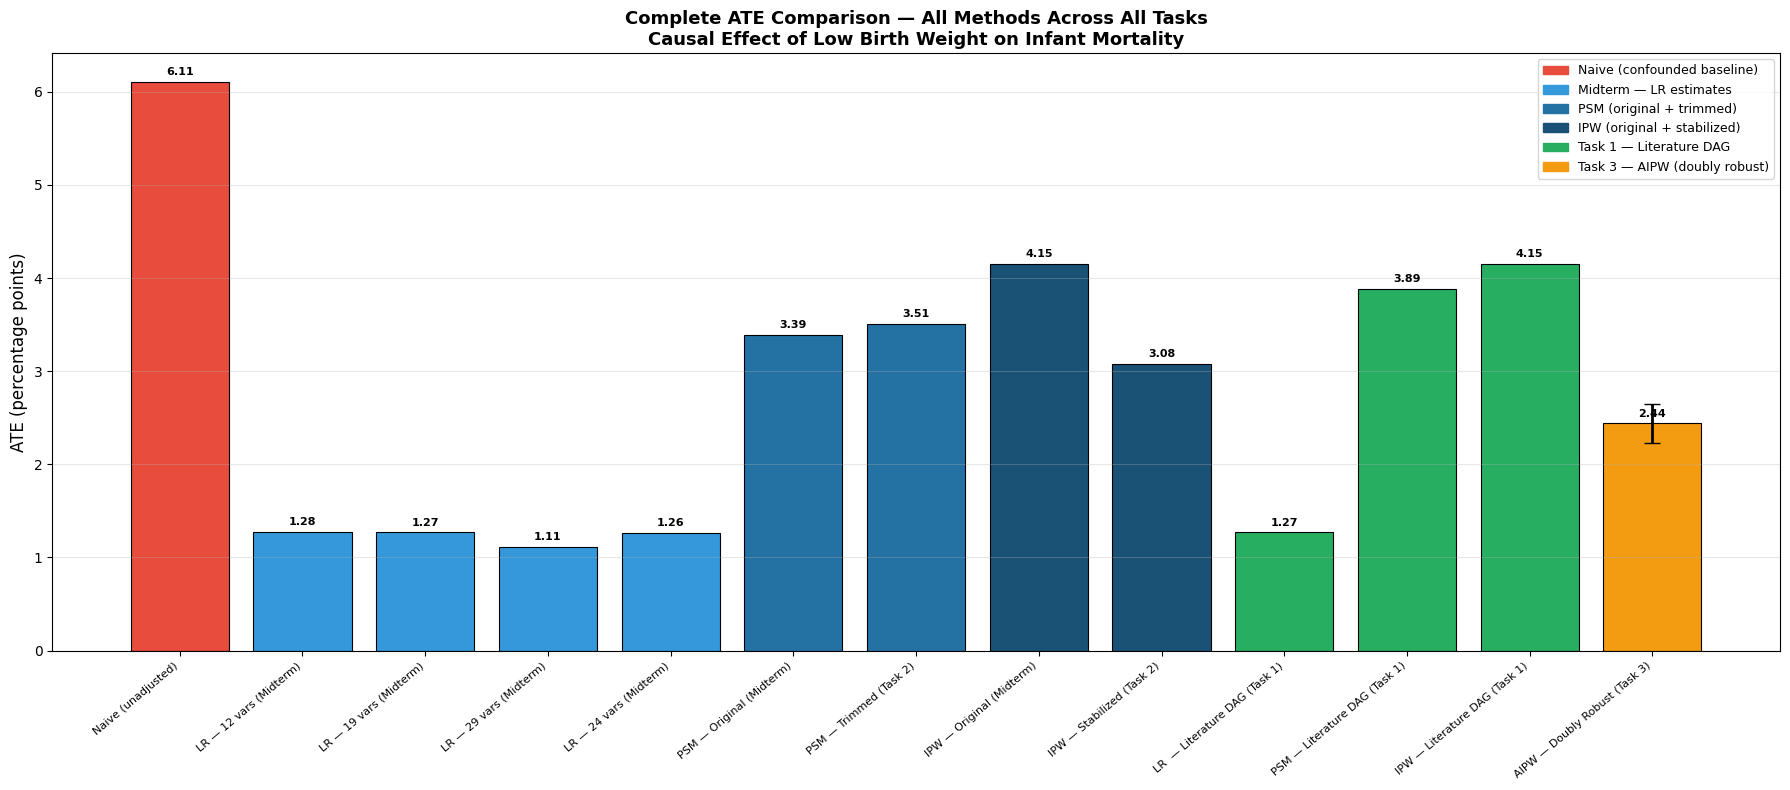

In [ ]:
# ─────────────────────────────────────────────────────────────
# STEP 6: Comprehensive results table — ALL tasks combined
# ─────────────────────────────────────────────────────────────

results_all_methods = pd.DataFrame({
    'Method': [
        'Naive (unadjusted)',
        'LR — 12 vars (Midterm)',
        'LR — 19 vars (Midterm)',
        'LR — 29 vars (Midterm)',
        'LR — 24 vars (Midterm)',
        'PSM — Original (Midterm)',
        'PSM — Trimmed (Task 2)',
        'IPW — Original (Midterm)',
        'IPW — Stabilized (Task 2)',
        'LR  — Literature DAG (Task 1)',
        'PSM — Literature DAG (Task 1)',
        'IPW — Literature DAG (Task 1)',
        'AIPW — Doubly Robust (Task 3)'
    ],
    'ATE (pp)': [
        6.11,
        round(ate_12 * 100, 4),
        round(ate_19 * 100, 4),
        round(ate_29 * 100, 4),
        round(ate_24 * 100, 4),
        round(ate_psm * 100, 4),
        round(psm_trimmed * 100, 4),
        round(ate_ipw * 100, 4),
        round(ipw_trim_stabilized * 100, 4),
        round(estimate_dag_lr.value * 100, 4),
        round(estimate_dag_psm.value * 100, 4),
        round(estimate_dag_ipw.value * 100, 4),
        round(aipw_ate * 100, 4)
    ],
    'Task': [
        'Baseline',
        'Midterm', 'Midterm', 'Midterm', 'Midterm',
        'Midterm', 'Task 2',
        'Midterm', 'Task 2',
        'Task 1', 'Task 1', 'Task 1',
        'Task 3'
    ]
})

print("="*60)
print("COMPLETE RESULTS — ALL METHODS ACROSS ALL TASKS")
print("="*60)
print(results_all_methods.to_string(index=False))

print()
print("="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Naive ATE                    : 6.1100 pp")
print(f"  LR ATE (24-var)              : "
      f"{ate_24*100:.4f} pp")
print(f"  Stabilized IPW ATE (Task 2)  : "
      f"{ipw_trim_stabilized*100:.4f} pp")
print(f"  Literature DAG LR (Task 1)   : "
      f"{estimate_dag_lr.value*100:.4f} pp")
print(f"  AIPW ATE (Task 3)            : "
      f"{aipw_ate*100:.4f} pp")
print(f"  95% CI (AIPW)                : "
      f"[{aipw_ci_lower*100:.4f}, {aipw_ci_upper*100:.4f}] pp")
print(f"  Confounding bias removed     : "
      f"{6.11 - aipw_ate*100:.4f} pp")

# ─────────────────────────────────────────────────────────────
# Bar Chart — All methods
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 8))

bar_colors = (
    ['#E74C3C']      +   # Naive
    ['#3498DB'] * 4  +   # Midterm LR
    ['#2471A3'] * 2  +   # Midterm/Trimmed PSM
    ['#1A5276'] * 2  +   # Midterm/Stabilized IPW
    ['#27AE60'] * 3  +   # Task 1 DAG
    ['#F39C12']          # Task 3 AIPW
)

bars = ax.bar(
    range(len(results_all_methods)),
    results_all_methods['ATE (pp)'],
    color=bar_colors,
    edgecolor='black',
    linewidth=0.8
)

# Value labels on bars
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2.,
        h + 0.05,
        f'{h:.2f}',
        ha='center', va='bottom',
        fontsize=8, fontweight='bold'
    )

# AIPW confidence interval error bar
aipw_idx = len(results_all_methods) - 1
ax.errorbar(
    aipw_idx,
    aipw_ate * 100,
    yerr=[[aipw_ate*100 - aipw_ci_lower*100],
          [aipw_ci_upper*100 - aipw_ate*100]],
    fmt='none',
    color='black',
    capsize=6,
    linewidth=2
)

ax.set_xticks(range(len(results_all_methods)))
ax.set_xticklabels(
    results_all_methods['Method'],
    rotation=40, ha='right', fontsize=8
)
ax.set_ylabel('ATE (percentage points)', fontsize=12)
ax.set_title(
    'Complete ATE Comparison — All Methods Across All Tasks\n'
    'Causal Effect of Low Birth Weight on Infant Mortality',
    fontsize=13, fontweight='bold'
)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

legend_elements = [
    mpatches.Patch(color='#E74C3C',
                   label='Naive (confounded baseline)'),
    mpatches.Patch(color='#3498DB',
                   label='Midterm — LR estimates'),
    mpatches.Patch(color='#2471A3',
                   label='PSM (original + trimmed)'),
    mpatches.Patch(color='#1A5276',
                   label='IPW (original + stabilized)'),
    mpatches.Patch(color='#27AE60',
                   label='Task 1 — Literature DAG'),
    mpatches.Patch(color='#F39C12',
                   label='Task 3 — AIPW (doubly robust)'),
]
ax.legend(handles=legend_elements,
          fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# TASK 4: DOWHY REFUTATION TESTS
# Robustness checks for the Literature DAG Linear Regression estimate
# ============================================================

print("="*60)
print("TASK 4: DOWHY REFUTATION TESTS")
print("="*60)

original_ate = estimate_dag_lr.value

print(f"Original Literature DAG LR ATE: {original_ate*100:.4f} pp")

TASK 4: DOWHY REFUTATION TESTS
Original Literature DAG LR ATE: 1.2704 pp


In [ ]:
# Refuter 1: Random Common Cause
# Adds a fake random confounder. Estimate should not change much.

refute_random = model_dag.refute_estimate(
    identified_dag,
    estimate_dag_lr,
    method_name="random_common_cause",
    random_seed=42
)

print("="*60)
print("REFUTER 1: RANDOM COMMON CAUSE")
print("="*60)
print(refute_random)

REFUTER 1: RANDOM COMMON CAUSE
Refute: Add a random common cause
Estimated effect:0.012704024755004404
New effect:0.012703979298674515
p value:0.94



In [ ]:
# Refuter 2: Placebo Treatment
# Replaces real treatment with random/placebo treatment.
# New effect should be close to 0.

refute_placebo = model_dag.refute_estimate(
    identified_dag,
    estimate_dag_lr,
    method_name="placebo_treatment_refuter",
    placebo_type="permute",
    random_seed=42
)

print("="*60)
print("REFUTER 2: PLACEBO TREATMENT")
print("="*60)
print(refute_placebo)

REFUTER 2: PLACEBO TREATMENT
Refute: Use a Placebo Treatment
Estimated effect:0.012704024755004404
New effect:-0.00018527361650620585
p value:0.68



In [ ]:
# Refuter 3: Data Subset
# Re-estimates effect on random subsets of the data.
# Estimate should remain close to original.

refute_subset = model_dag.refute_estimate(
    identified_dag,
    estimate_dag_lr,
    method_name="data_subset_refuter",
    subset_fraction=0.8,
    num_simulations=10,
    random_seed=42
)

print("="*60)
print("REFUTER 3: DATA SUBSET")
print("="*60)
print(refute_subset)

             Note: The underlying distribution may not be Normal. We assume that it approaches normal with the increase in sample size.


REFUTER 3: DATA SUBSET
Refute: Use a subset of data
Estimated effect:0.012704024755004404
New effect:0.012988937308710091
p value:0.19104085529199516



In [ ]:
# Summary table for presentation

task4_results = pd.DataFrame({
    "Refutation Test": [
        "Random Common Cause",
        "Placebo Treatment",
        "Data Subset"
    ],
    "Purpose": [
        "Checks whether adding fake confounder changes result",
        "Checks whether random fake treatment gives near-zero effect",
        "Checks whether estimate is stable across data subsets"
    ],
    "Original ATE (pp)": [
        original_ate * 100,
        original_ate * 100,
        original_ate * 100
    ],
    "Interpretation": [
        "Robust if new estimate remains close to original",
        "Robust if placebo estimate is close to 0",
        "Robust if subset estimate remains close to original"
    ]
})

task4_results

,Refutation Test,Purpose,Original ATE (pp),Interpretation
0,Random Common Cause,Checks whether adding fake confounder changes ...,1.270402,Robust if new estimate remains close to original
1,Placebo Treatment,Checks whether random fake treatment gives nea...,1.270402,Robust if placebo estimate is close to 0
2,Data Subset,Checks whether estimate is stable across data ...,1.270402,Robust if subset estimate remains close to ori...


In [ ]:
# ============================================================
# TASK 5A: E-VALUE SENSITIVITY ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

print("="*60)
print("TASK 5A: E-VALUE SENSITIVITY ANALYSIS")
print("="*60)

# Use AIPW outcome model potential outcome risks
risk_treated = mu1_aipw.mean()
risk_control = mu0_aipw.mean()

risk_ratio = risk_treated / risk_control

def calculate_evalue(rr):
    """
    E-value for risk ratio.
    For harmful effect RR > 1:
    E-value = RR + sqrt(RR * (RR - 1))
    """
    if rr < 1:
        rr = 1 / rr
    return rr + np.sqrt(rr * (rr - 1))

evalue = calculate_evalue(risk_ratio)

print(f"Estimated risk if LBW      : {risk_treated*100:.4f}%")
print(f"Estimated risk if not LBW  : {risk_control*100:.4f}%")
print(f"Risk Ratio                 : {risk_ratio:.4f}")
print(f"E-value                    : {evalue:.4f}")

TASK 5A: E-VALUE SENSITIVITY ANALYSIS
Estimated risk if LBW      : 2.9869%
Estimated risk if not LBW  : 1.4658%
Risk Ratio                 : 2.0378
E-value                    : 3.4920


In [ ]:
task5_evalue_table = pd.DataFrame({
    "Measure": [
        "Risk if LBW",
        "Risk if not LBW",
        "Risk Ratio",
        "E-value"
    ],
    "Value": [
        f"{risk_treated*100:.4f}%",
        f"{risk_control*100:.4f}%",
        f"{risk_ratio:.4f}",
        f"{evalue:.4f}"
    ],
    "Interpretation": [
        "Estimated mortality risk under treatment",
        "Estimated mortality risk under control",
        "Relative increase in mortality risk",
        "Minimum unmeasured confounding strength needed to explain away effect"
    ]
})

task5_evalue_table

,Measure,Value,Interpretation
0,Risk if LBW,2.9869%,Estimated mortality risk under treatment
1,Risk if not LBW,1.4658%,Estimated mortality risk under control
2,Risk Ratio,2.0378,Relative increase in mortality risk
3,E-value,3.4920,Minimum unmeasured confounding strength needed...


In [ ]:
# ============================================================
# TASK 5B: ROSENBAUM SENSITIVITY ANALYSIS FOR MATCHED PAIRS
# ============================================================

from scipy.stats import binom

print("="*60)
print("TASK 5B: ROSENBAUM SENSITIVITY ANALYSIS")
print("="*60)

# Recreate matched pairs from Task 2
treated = df_trim[df_trim['treatment'] == 1].copy()
control = df_trim[df_trim['treatment'] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['pscore']])

distances, indices = nn.kneighbors(treated[['pscore']])
matched_control = control.iloc[indices.flatten()].copy()

# Outcomes for matched treated-control pairs
y_treated = treated['outcome'].values
y_control = matched_control['outcome'].values

# Discordant pairs only:
# treated death = 1, control death = 0 means harmful treated effect
treated_worse = np.sum((y_treated == 1) & (y_control == 0))
control_worse = np.sum((y_treated == 0) & (y_control == 1))

n_discordant = treated_worse + control_worse

print(f"Treated worse pairs : {treated_worse}")
print(f"Control worse pairs : {control_worse}")
print(f"Discordant pairs    : {n_discordant}")

TASK 5B: ROSENBAUM SENSITIVITY ANALYSIS
Treated worse pairs : 3268
Control worse pairs : 798
Discordant pairs    : 4066


In [ ]:
# Rosenbaum bounds over different Gamma values
# Gamma = 1 means no hidden bias.
# Higher Gamma means more hidden bias allowed.

gamma_values = [1.0, 1.1, 1.2, 1.5, 2.0, 2.5, 3.0]

rosenbaum_results = []

for gamma in gamma_values:
    p_upper = gamma / (1 + gamma)
    p_lower = 1 / (1 + gamma)

    # One-sided p-value for harmful LBW effect
    upper_p_value = binom.sf(treated_worse - 1, n_discordant, p_upper)
    lower_p_value = binom.sf(treated_worse - 1, n_discordant, p_lower)

    rosenbaum_results.append({
        "Gamma": gamma,
        "p_lower_bound": lower_p_value,
        "p_upper_bound": upper_p_value,
        "Robust at 0.05?": upper_p_value < 0.05
    })

rosenbaum_table = pd.DataFrame(rosenbaum_results)
rosenbaum_table

,Gamma,p_lower_bound,p_upper_bound,Robust at 0.05?
0,1.0,0.0,0.000000e+00,True
1,1.1,0.0,7.297240e-303,True
2,1.2,0.0,1.674649e-261,True
3,1.5,0.0,1.736870e-170,True
4,2.0,0.0,4.798654e-84,True
5,2.5,0.0,1.971054e-39,True
6,3.0,0.0,2.652587e-16,True


In [ ]:
!pip install pyro-ppl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.1 MB/s eta 0:00:00
